# For plotting comparision Graphs

In [17]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [26]:
%matplotlib inline

In [18]:
base=pd.read_excel('Base.xlsx')

In [43]:
base.head(9)

,Algorithms,Train Accuracy(%),Test Accuracy (%),Precision (%),Recall (%),F1 score (%)
0,ZeroR (baseline),40,36,79,33,18
1,Decision Tree,100,60,60,60,59
2,Random Forest,100,57,60,57,57
3,Support Vector,72,65,68,65,66
4,Gradient Boosting,96,63,67,62,63
5,Logistic Regression,70,60,61,59,60
6,AdaBoost,62,55,57,56,56
7,K-Nearest Neighbour,69,60,60,60,60
8,Naive Bayes,63,59,62,58,59


In [20]:
feature=pd.read_excel('Feature.xlsx')

In [21]:
feature.head()

,Algorithms,Train Accuracy(%),Test Accuracy (%),Precision (%),Recall (%),F1 score (%)
0,Decision Tree,100,59,60,59,59
1,Random Forest,100,67,68,67,68
2,Gradient Boosting,90,58,60,58,58
3,Logistic Regression,69,62,63,62,62
4,AdaBoost,62,55,57,56,56


In [22]:
hyper=pd.read_excel('Hyper.xlsx')

In [23]:
hyper.head()

,Algorithms,Train GridSearchCV (%),Test GridSearchCV (%),Train RandomizedSearchCV (%),Test RandomizedSearchCV (%),Train Optuna (%),Test Optuna (%)
0,Decision Tree,71,61,71,65,68,62
1,Random Forest,82,61,80,59,89,65
2,Support Vector,73,61,81,65,70,65
3,Gradient Boosting,64,53,73,75,99,64
4,Logistic Regression,65,63,65,63,62,62


In [24]:
feathyp=pd.read_excel('Feature_Hyper.xlsx')

In [25]:
feathyp.head()

,Algorithms,Train GridSearchCV (%),Test GridSearchCV (%),Train RandomizedSearchCV (%),Test RandomizedSearchCV (%),Train Optuna (%),Test Optuna (%)
0,Decision Tree,71,62,74,63,79,70
1,Random Forest,76,64,81,63,79,71
2,Gradient Boosting,64,53,64,53,73,69
3,Logistic Regression,64,71,64,71,68,72
4,AdaBoost,62,65,62,65,61,69


# Matplotlib SaveFig

In [27]:
# extra code – code to save the figures as high-res PNGs
import os
from pathlib import Path

IMAGES_PATH = Path() / "images" / "metrics"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

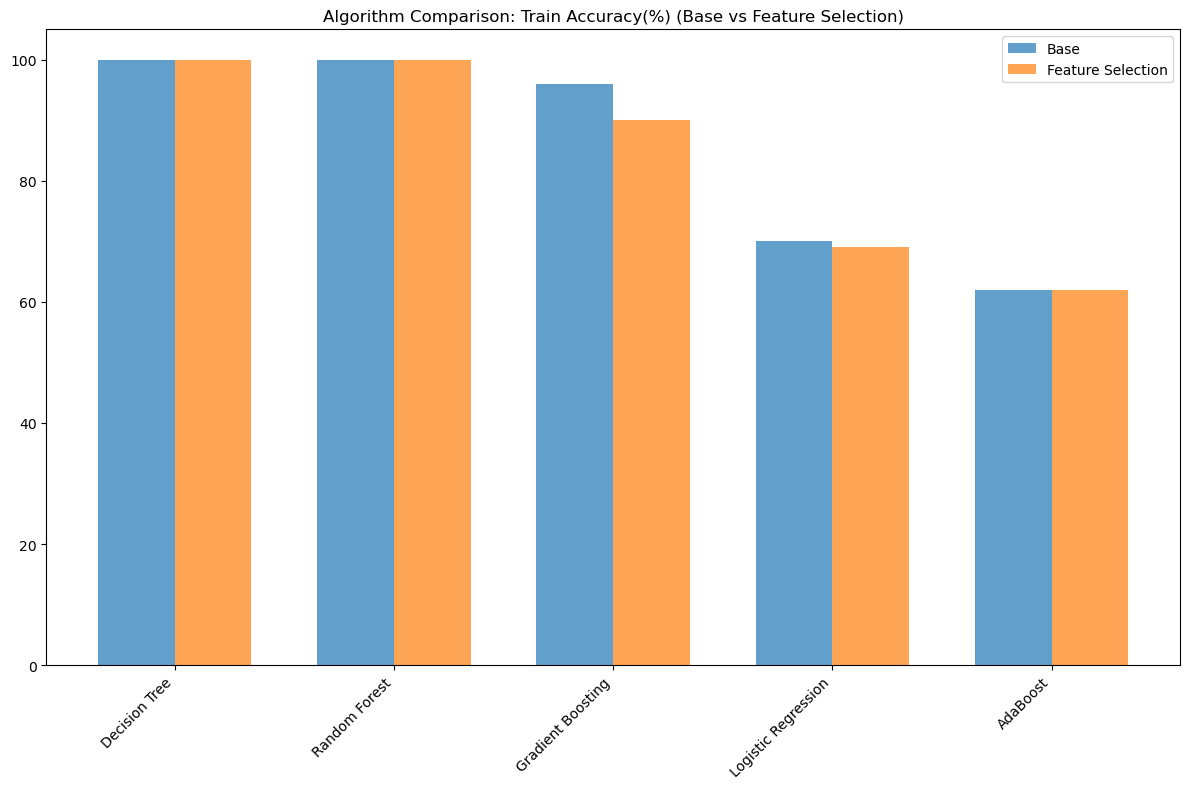

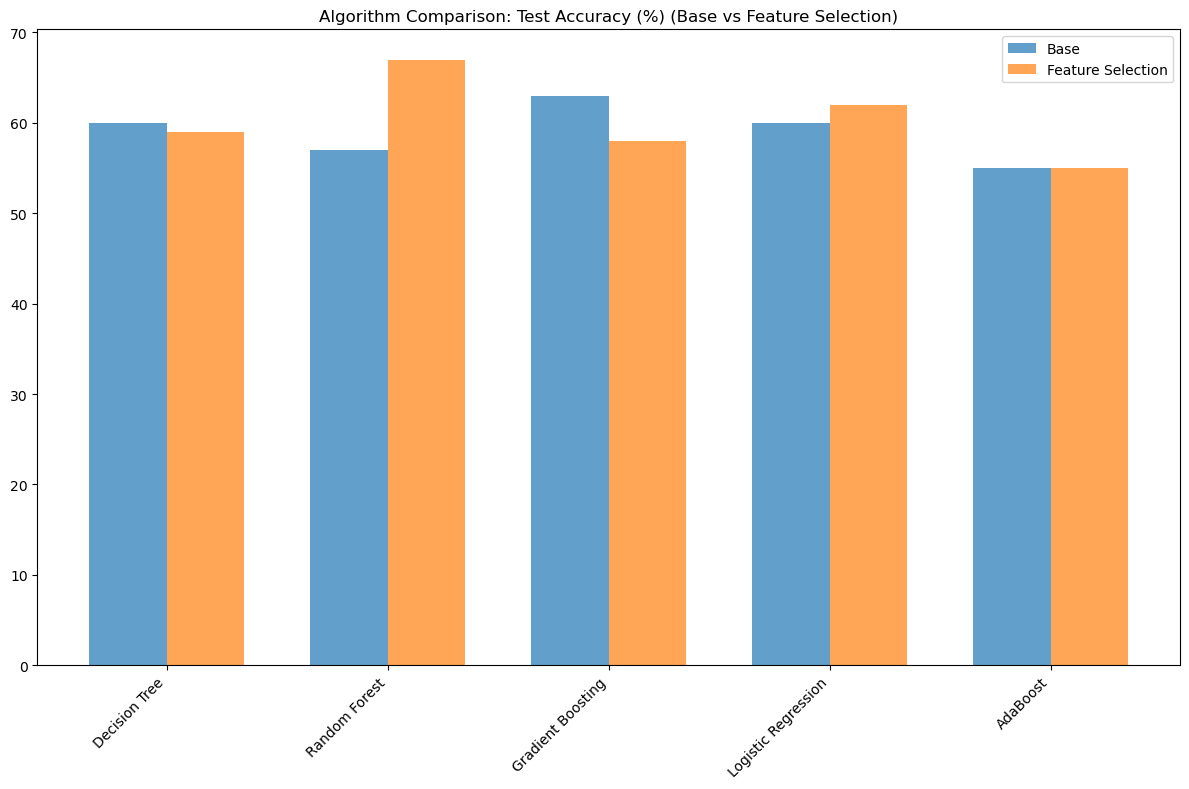

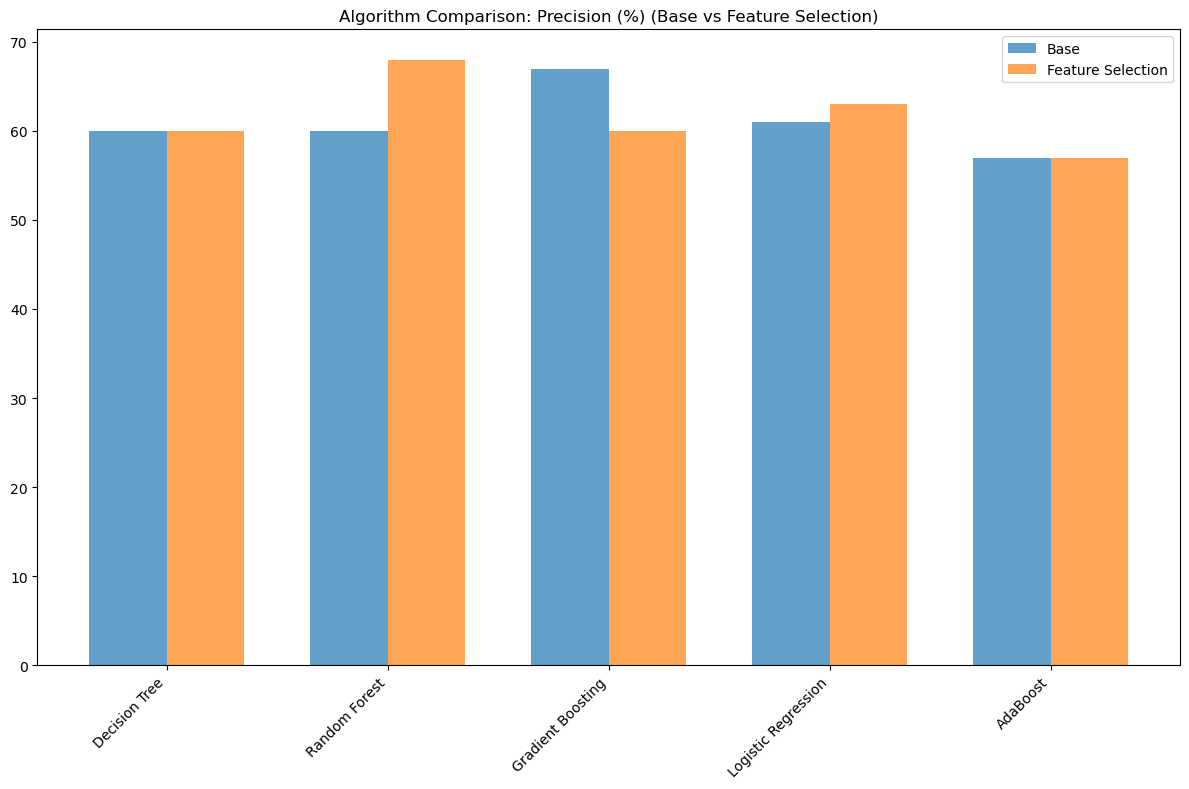

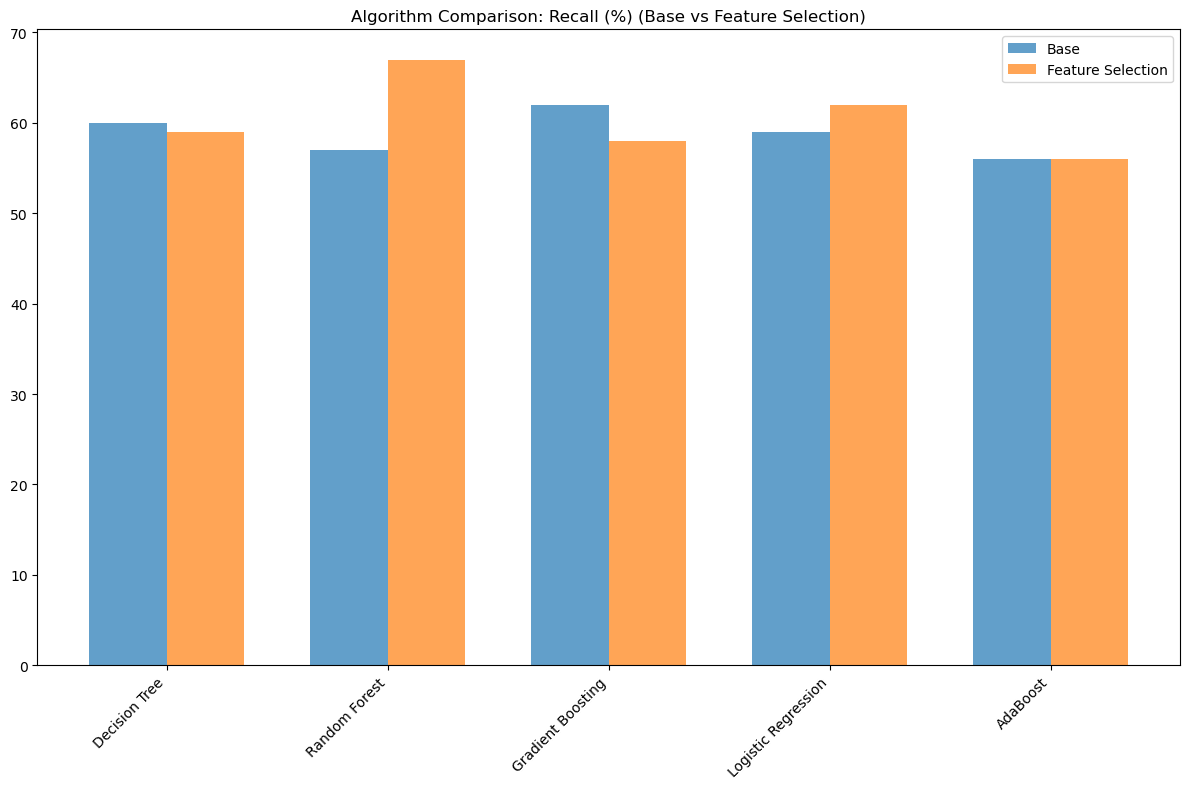

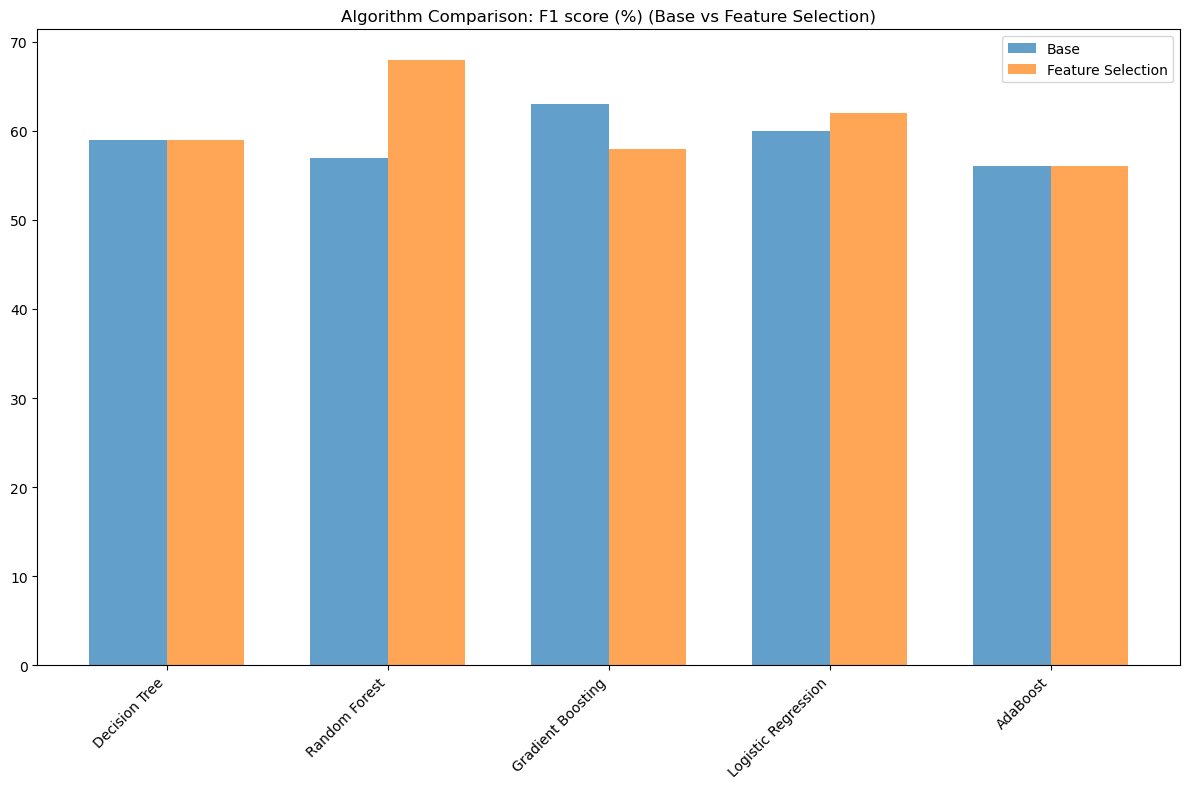

In [59]:
# Metrics to compare
metrics = ['Train Accuracy(%)', 'Test Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 score (%)']
counter=0
# Separate plot for each metric
for metric in metrics:
    # Filter algorithms that are present in both base and feature dataframes
    common_algorithms = set(base['Algorithms']).intersection(feature['Algorithms'])
    base_filtered = base[base['Algorithms'].isin(common_algorithms)]
    feature_filtered = feature[feature['Algorithms'].isin(common_algorithms)]

    # Set the positions for the bars
    positions_base = np.arange(len(base_filtered['Algorithms']))
    positions_feature = positions_base + 0.35  # Shift the feature bars to the right

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.bar(positions_base, base_filtered[metric], width=0.35, label='Base', alpha=0.7)
    ax.bar(positions_feature, feature_filtered[metric], width=0.35, label='Feature Selection', alpha=0.7)

    ax.set_title(f'Algorithm Comparison: {metric} (Base vs Feature Selection)')
    ax.set_xticks(positions_base + 0.175)  # Center x ticks between base and feature bars
    ax.set_xticklabels(base_filtered['Algorithms'], rotation=45, ha='right')
    ax.legend()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    save_fig(f'BS_{counter}')
    counter=counter+1
    plt.show()